In [1]:
%matplotlib inline
import numpy as np
from numpy import random
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from operator import add
import itertools
from scipy import signal
import seaborn as sns
import nest


ModuleNotFoundError: No module named 'nest'

In [2]:
import os
import sys
Path = os.getcwd()
sys.path.append(Path)
print(os.getcwd())
from utilities1 import *
from build_simulation import *

/home/tonje/master/TIS


In [3]:

def find_I(V_target_si, f, tau_si=10e-3, R_si=100e6, E_m_si=-60e-3):
    a_si = (-E_m_si+V_target_si) * math.sqrt(1 + (2*math.pi*f*tau_si)**2) / R_si
    a = a_si/(1e-12)
    print(f"I_amp for f={f}: {a:.1f}pA")

def isi_dist(ts):
    isi = []
    
    for i in range(len(ts)-1):
        isi.append(ts[i+1]-ts[i])
    plt.figure()
    plt.hist(isi, bins=10, histtype='step')
    plt.title("Histogram")
    plt.ylabel("Frequency")
    plt.xlabel("Interspike interval")

In [ ]:
def plot_results(sim_time=5000, noisy=False, psd_segments=16, 
                  second_sine=False, xLim=0, a_values=[100],
                 SD_values=[250], f_values=[10], beat=20,
                 E_m=-60, V_th=-50, bin_size=1, 
                 seed=np.random.randint(0,1e+6), resolution=0.25, 
                 legend=False, log=True, y_min=1e-7, harmonics=1,
                 harmonics_beat=0, save_fig=False, autocorr_validation=False, 
                 welch=False, demean=False, normalize=False):
    
    """This function plots:
    - Membrane potential as a function of time for a given length within simulation time (xLim)
    - The PSD of the spike train
    - The PSD of the membrane potential
        noisy: whether to include noise or not (True/False)
        sim_time: duration of simulation (ms)
        psd_segments: number of segments in welch psd
        second_sine : whether to include second AC generator or not (True/False)
        xLim : limiting the time axis of the membrane potential (max value) (ms)
        a_values : input amplitudes (pA)
        SD_values : input noise level (standard deviation) (pA)
        f_values : input frequencies (Hz)
        beat : frequency offset (Hz)
        E_m : resting potential (mV)
        V_th : Threshold for firing action potentials (mV)
        bin_size : width of frequency (Hz)
        seed : random number (or set by user for control).
        Necessary for generation of stochastic noise,
        resolution : temporal resolution/length of time steps (ms)
        legend : Whether to put legend outside plots (True/False)
        log : Whether to use loglog-plot or not (True/False)
        y_min : min value for PSD of spike train (varies a lot)
        harmonics : number of harmonics of input frequencies indicated in PSD-plot
        harmonics_beat : number of harmonics of beat frequency indicated in PSD- plot"""    
    
    ###*************************SIMULATION***********************************
    if noisy:
        param_combos = [
        (f, a, sd) for f, a, sd in itertools.product(f_values, a_values, SD_values)
        if not (a == 0 and sd == 0)
        ]
    else:
        param_combos = list(itertools.product(f_values, a_values))
    
    param_combos = np.atleast_1d(param_combos) #to allow for one single combination
    
        
    fig, axes = plt.subplots(nrows=len(param_combos), ncols=3, 
                             figsize=(15, 5*len(param_combos)))
    
    if len(param_combos) == 1:
        axes = np.array([axes])
    
    for idx, combo  in enumerate(param_combos):
        if noisy:
            
            f, a, sd = combo
            results = build_simulation(sim_time=sim_time, noisy=noisy,
                                f1=f, a=a, SD=sd, V_thresh=V_th, E_m=E_m, 
                                   second_sine=second_sine,
                                    seed=seed, resolution=resolution)
                
                    
        else:
    
            f,a = combo
            results = build_simulation(sim_time=sim_time, noisy=noisy,
                                f1=f, a=a, V_thresh=V_th, E_m=E_m, 
                                second_sine=second_sine,
                                seed=seed, resolution=resolution)
                
         #********************************RESULTS AND PLOTS********************************   
        spike_times = results["spike_times"]
        Vm = results["Vm"]
        V_th = results["V_th"]
        sim_time = results["sim_time"]
        times = results["times"]

        #Background
        sns.set_style("whitegrid")
        plt.rcParams["font.family"] = "DejaVu Serif"
        # Membrane potential with threshold 
        
        ax_vm = axes[idx,0]
        time_axis = np.linspace(0,sim_time,len(Vm))
        
        for t in spike_times:
            ax_vm.vlines(x=t, ymin=V_th, ymax=V_th+5, color="black") 
            
        ax_vm.plot(time_axis, Vm, color='#006D5B')
        
        ax_vm.axhline(V_th, linestyle='-', color='black', label="V_th")  # terskel-linje
        
        #-----------------TITLES---------------------
        letters = "ABCDEFGHIJKLMN"
        
        if noisy:
            if second_sine:
                title = rf"{letters[3*idx]}. $V_m$ ($f_1$ = {f:.0f}Hz, $f_2$ = {(f+beat):.0f}Hz, " + rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)"
            else:
                title =  rf"{letters[3*idx]}. $V_m$ ($f$ = {f:.0f}Hz, $I_\sigma$ = {sd:.0f}pA, " + rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)"
             
        else:
            if second_sine:
                title = rf"{letters[3*idx]}. $V_m$ ($f_1$ = {f:.0f}Hz, $f_2$ = {(f+beat):.0f}Hz, " + rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)"
            else:
                title = rf"{letters[3*idx]}. $V_m$ ($f$ = {f:.0f}Hz, $I_{{\mathrm{{I}}}}$ = {a:.0f}pA)"
                
                
        if a == 0:
            
            if second_sine == False:
                title = title.replace(r"($f$ = " + f"{f:.0f}" + r"Hz, ", "(")
    
            if second_sine: 
                title = title.replace(r"($f_1$ = " + f"{f:.0f}" + r"Hz, $f_2$ = " + f"{f + beat:.0f}" + r"Hz, ", "(")
        
        ax_vm.set_title(title,fontsize=18, fontweight='bold', color="#006D5B")
        
            


        ax_vm.set_xlim([0, sim_time])
        if xLim != 0:
            ax_vm.set_xlim(1000, 1000+1000*xLim) 
        dV = np.max(Vm-E_m)
        #ax_vm.set_ylim([np.min(Vm)-0.03*dV,np.max(Vm)+0.5*dV])
        ax_vm.set_ylim([-70,-48])
        #ax_vm.set_ylim(-65,-55)
        ax_vm.set_xlabel("Time [ms]", color="#006D5B", fontsize=16)
        ax_vm.set_ylabel("$V_m$ [mV]", color="#006D5B",fontsize=16)
        
        #chat-gpt:
        ax_vm.set_facecolor("#F5F5F5")
        ax_vm.spines["top"].set_visible(False)
        ax_vm.spines["right"].set_visible(False)
        ax_vm.spines["left"].set_color("#333333")
        ax_vm.spines["bottom"].set_color("#333333")
        ax_vm.xaxis.label.set_color("#006D5B")
        ax_vm.yaxis.label.set_color("#006D5B")
        ax_vm.tick_params(axis='both', colors="#333333", labelsize='large')
        ax_vm.grid(color='#A3D4CC', linestyle='-', linewidth=0.5)
        ax_vm.legend(facecolor="white", framealpha=1, edgecolor="#333333", fontsize=16)
        
    
        
        # PSD of spike train (Welchs method)
        if welch:
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size, segments=psd_segments, 
                                          f=f, demean=demean, normalize=normalize)
            print("psd values", psd_values)
            
        else:
            freqs, psd_values = psd(spike_times, bin_size, sim_time, f=f, demean=demean)
        # PSD of autocorrelation of spiketrain

        ax_fft = axes[idx,1]
        
        
            
        arg_f = np.argmin(np.abs(freqs - f))
        
        
        if second_sine:
            arg_f = np.argmin(np.abs(freqs - f))
    
       
        
        
        # Vertical lines, colors filled in by chat GPT
        
        beat_colors = ["#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
        colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B"]  # Green colors for harmonics
        
        for i in range(1,harmonics_beat+1):
            ax_fft.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"f={i*beat}Hz")
            
        for i in range(1,harmonics+1):
            ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"f={i*f}Hz")
            if second_sine:
                ax_fft.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"f={i*(f+beat)}Hz")
            ax_fft.legend()
        
        keep_args = psd_values > 1e-30
        psd_values = psd_values[keep_args]
        freqs = freqs[keep_args]

        ax_fft.plot(freqs, psd_values, color="#006D5B") 

        auto_values = None
        freqs_auto = None

        if autocorr_validation:
            if welch:
                freqs_auto, auto_values = welch_autocorr(spike_times, bin_size, sim_time,
                                                         segments=psd_segments, f=f, demean=demean,
                                                         normalize=normalize)
                
                print("autocorr psd values", auto_values)
            else:
                freqs_auto, auto_values = psd_autocorr(spike_times, bin_size,  sim_time, f, demean)

            arg_f_auto = np.argmin(np.abs(freqs_auto - f))
            arg_f_auto = np.argmin(np.abs(freqs_auto - f))
            arg_f_auto = np.argmin(np.abs(freqs_auto - f))
            keep_args = auto_values > 1e-30
            auto_values = auto_values[keep_args]
            freqs_auto = freqs_auto[keep_args]
            ax_fft.plot(freqs_auto, auto_values, color="midnightblue", alpha=0.25, label="autocorr") 
            
        if len(freqs) > 0:
            xMax = max(f,np.max(freqs))*1.1
            
            
        #-----------Create empty log-plot if there are no PSD-values----------   
        if len(psd_values) == 0:
        
            ax_fft.loglog([1], [1e-16], alpha=0)  
            ax_fft.set_xlim(1, 2e3)
            ax_fft.set_ylim(1e-16, 1e-10)
            ax_fft.set_title("PSD of spike train (No spikes)", fontsize=14, fontweight="bold", color="#006D5B")
            ax_fft.set_xscale("log")
            ax_fft.set_yscale("log")
            
        if len(psd_values) > 0:
            ymin = max(3e-5, np.min(np.abs(psd_values)))
            ymax = np.max(np.abs(psd_values))*1.1
            if autocorr_validation == True:
                ymin = max(1e-9, np.min(np.abs(auto_values)))
                ymax = max(3e-5, np.min(np.abs(auto_values)))
            #ax_fft.set_ylim(ymin,ymax)
            ax_fft.set_xscale("log")
            ax_fft.set_yscale("log")
        
        ax_fft.set_xlim(1,2e3)
        ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
        ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
        ax_fft.set_title(f"{letters[1+3*idx]}. PSD of spike train", fontsize=20, fontweight='bold', color="#006D5B")
        if autocorr_validation:
            ax_fft.set_title(f"{letters[1+3*idx]}. Normalized PSD of spiketrain", fontsize=18, fontweight='bold', color="#006D5B")
            
        # Generated by ChatGPT (adapted afterwards):
        ax_fft.set_facecolor("#F5F5F5")
        ax_fft.spines["top"].set_visible(False)
        ax_fft.spines["right"].set_visible(False)
        ax_fft.spines["left"].set_color("#333333")
        ax_fft.spines["bottom"].set_color("#333333")
        ax_fft.xaxis.label.set_color("#006D5B")
        ax_fft.yaxis.label.set_color("#006D5B")
        ax_fft.tick_params(axis='both', colors="#333333", labelsize='large')
        
        # enabling placement of legend outside plots if necessary
        if legend:
            ax_fft.legend(edgecolor="#333333", fontsize=16, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
        else:
            ax_fft.legend(facecolor="white", framealpha=1, edgecolor="#333333", fontsize=16)
        
        # Calculating simulated SNR
        if len(psd_values) > 0:
            if noisy:
                if second_sine:
                    df, noise_avg = simulated_SNR(Vm, a, psd_values, f, freqs, 
                      arg_f, sim_time, sd, beat, spike_times, second_sine, freqs_auto, auto_values)
                else:
                    df, noise_avg = simulated_SNR(Vm, a, psd_values, f, freqs, 
                      arg_f, sim_time, sd, beat, spike_times, second_sine,
                      freqs_auto, auto_values)   
                    
                display(df)
          
    
        # PSD of membrane potential
        freqs, psd_vm = psd_Vm(Vm, times, resolution)
        psd_vm = np.abs(psd_vm)
        keep_args = psd_vm > 1e-30
        psd_vm = psd_vm[keep_args]
        freqs = freqs[keep_args]
    
        ax_fft_vm = axes[idx,2]
        for i in range(1,harmonics_beat+1):
            ax_fft_vm.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"f={i*beat}Hz")
            
        for i in range(1,harmonics+1):
            ax_fft_vm.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"f={i*f:.0f}Hz")
            if second_sine:
                ax_fft_vm.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"f={i*(f+beat):.0f}Hz")
            
        #if normalize_psd:
        #    psd_vm = psd_vm / np.max(psd_vm)
        
        ax_fft_vm.plot(freqs, np.abs(psd_vm), color='#006D5B')  
        
        if autocorr_validation: 
            freqs_auto, vm_auto_values = psd_Vm_autocorr(Vm, sim_time, bin_size, resolution)
            print("len vm auto values", len(vm_auto_values))
            print("len freqqs auto", len(freqs_auto))
            arg_f_auto = np.argmin(np.abs(freqs_auto - f))
            keep_args = vm_auto_values > 1e-30
            vm_auto_values = vm_auto_values[keep_args]
            #if normalize_psd:
            #    vm_auto_values = vm_auto_values / np.max(vm_auto_values)
            #    ax_fft_vm.set_title(f"{letters[2+3*idx]}. Normalized PSD of $V_m$", fontsize=18, fontweight='bold', color="#006D5B")
            #else:
            ax_fft_vm.set_title(f"{letters[2+3*idx]}. PSD of $V_m$", fontsize=20, fontweight='bold', color="#006D5B")


            freqs_auto = freqs_auto[keep_args]
            ax_fft_vm.plot(freqs_auto, vm_auto_values, color="midnightblue", alpha=0.25, label="autocorr") 
            

        ax_fft_vm.set_xlim(1, 2e3)           
        if len(psd_vm) > 0:
            ymin = max(y_min, np.min(np.abs(psd_vm)))
            if autocorr_validation == True:
                ymin = np.min(np.abs(vm_auto_values))
            ax_fft_vm.set_ylim(ymin,10*np.max(np.abs(psd_vm)))
        
            
      
        ax_fft_vm.set_xlabel("Frequency [Hz]", color="#006D5B", fontsize=16)
        ax_fft_vm.set_ylabel(r'PSD [$\mathrm{mV}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
        
        
        if log and len(psd_vm)>0:
            ax_fft_vm.set_xscale("log")
            ax_fft_vm.set_yscale("log")
        
        #generated by chatGPT
        ax_fft_vm.set_facecolor("#F5F5F5")
        ax_fft_vm.spines["top"].set_visible(False)
        ax_fft_vm.spines["right"].set_visible(False)
        ax_fft_vm.spines["left"].set_color("#333333")
        ax_fft_vm.spines["bottom"].set_color("#333333")
        ax_fft_vm.xaxis.label.set_color("#006D5B")
        ax_fft_vm.yaxis.label.set_color("#006D5B")
        ax_fft_vm.tick_params(axis='both', colors="#333333", labelsize='large')
        ax_fft_vm.grid(color='#B0B0B0', linestyle='-', linewidth=0.5)
    
        if legend:
            continue
        else:
            ax_fft_vm.legend(facecolor="white", framealpha=1, edgecolor="#333333", fontsize=16)
        
    
    plt.tight_layout()
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"main_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"main_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        
        print(f"Saved plot as: {save_path}")
        
    plt.show()
    
    
    
    

In [6]:
import math 

def calculate_SD(tau_si, C_m_si, Vm_SD, delta):
    SD_si = math.sqrt( (2 * C_m_si**2 * Vm_SD**2) / (delta * tau_si ))
    SD = SD_si / (1e-12)
    return SD

SD = calculate_SD(tau_si=10*1e-3, C_m_si=100*1e-12, Vm_SD=4.0*1e-3, delta=5e-4)
print(f"Resolution = 1.0 ms. SD I_noise: {SD:.2f} pA")

SD = calculate_SD(tau_si=10*1e-3, C_m_si=100*1e-9, Vm_SD=4.0*1e-3, delta=5e-4)
print(SD)

Resolution = 1.0 ms. SD I_noise: 252.98 pA
252982.21281347034


In [6]:
find_I(-51e-3, 10)

I_amp for f=10: 106.3pA



Mar 03 14:59:27 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Mar 03 14:59:27 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.


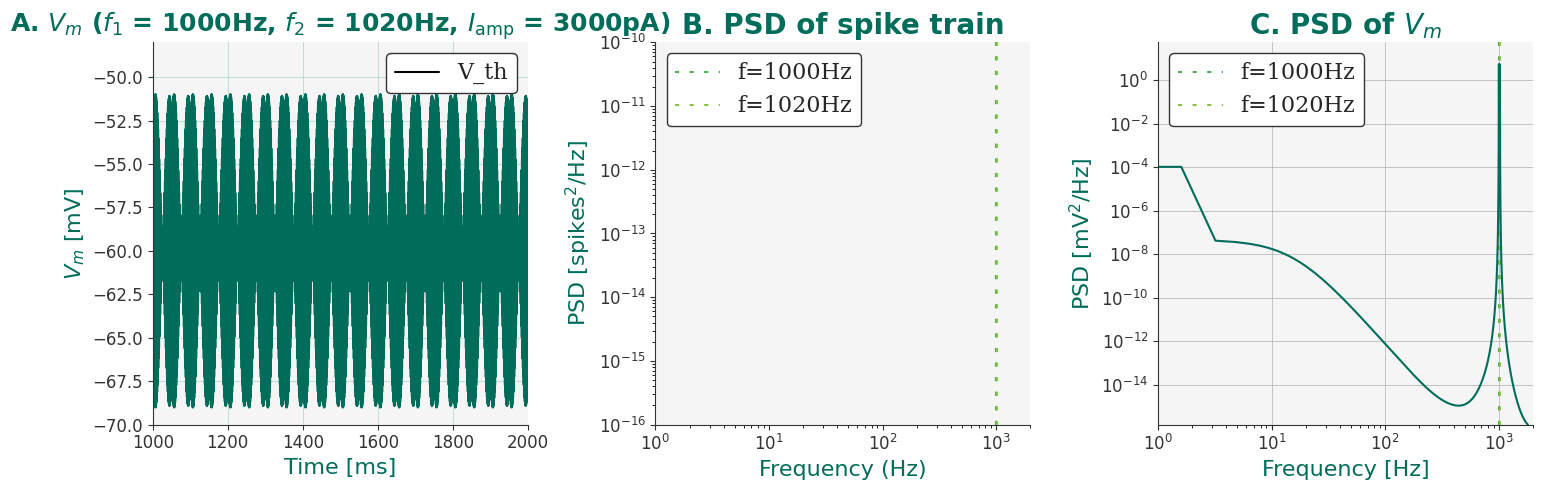

In [7]:
plot_results(sim_time=10e3,
             a_values=[3000],f_values=[1000], SD_values=[0],
             noisy=False, xLim=1, seed=2,V_th=0,
             bin_size=0.25, second_sine=True, harmonics=1,beat=20,
             resolution=0.25, y_min=1e-16)

psd values [ 3.59397304 15.99112184 20.03995703 ... 25.60493558 25.91988466
 26.69233104]
arg_f: 125


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,20,100,-50.000966,5.186622,567.24,567.24,20.0,28.98,19.58,9.85


Saved plot as: /home/tonje/master/TIS/results/main_113.png


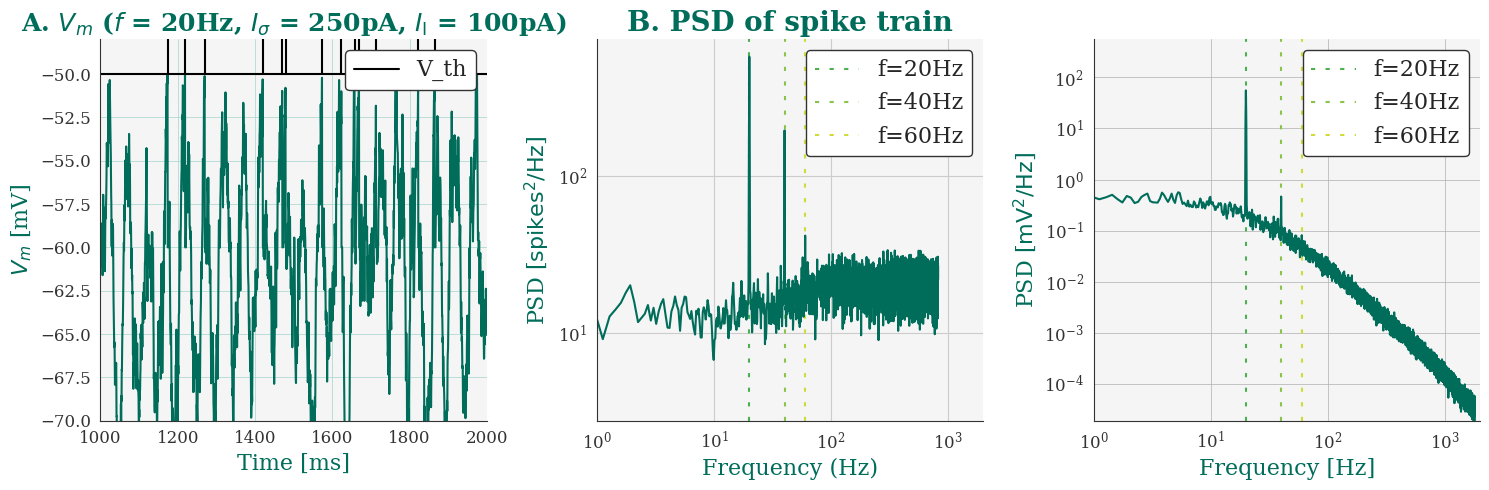

In [9]:
# fig 1 - original
plot_results(sim_time=100e3,
             a_values=[100],f_values=[20], SD_values=[250],
             noisy=True, xLim=1, seed=2,
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16,
              welch=True, normalize=False, demean=False)


Apr 03 11:21:10 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 03 11:21:10 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
len spike rate 400000
psd values [0.00633593 0.02819126 0.03532908 ... 0.04513975 0.04569499 0.04705676]
autocorr psd values [0.01267352 0.01787347 0.02819206 ... 0.04945993 0.04566809 0.03612865]
entered block


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s),SNR (autocorr),f at max (autocorr)
0,20,100,-50.000966,5.186622,1.0,1.0,20.0,28.98,0.03,9.85,23.578431,20.0004


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_88.png


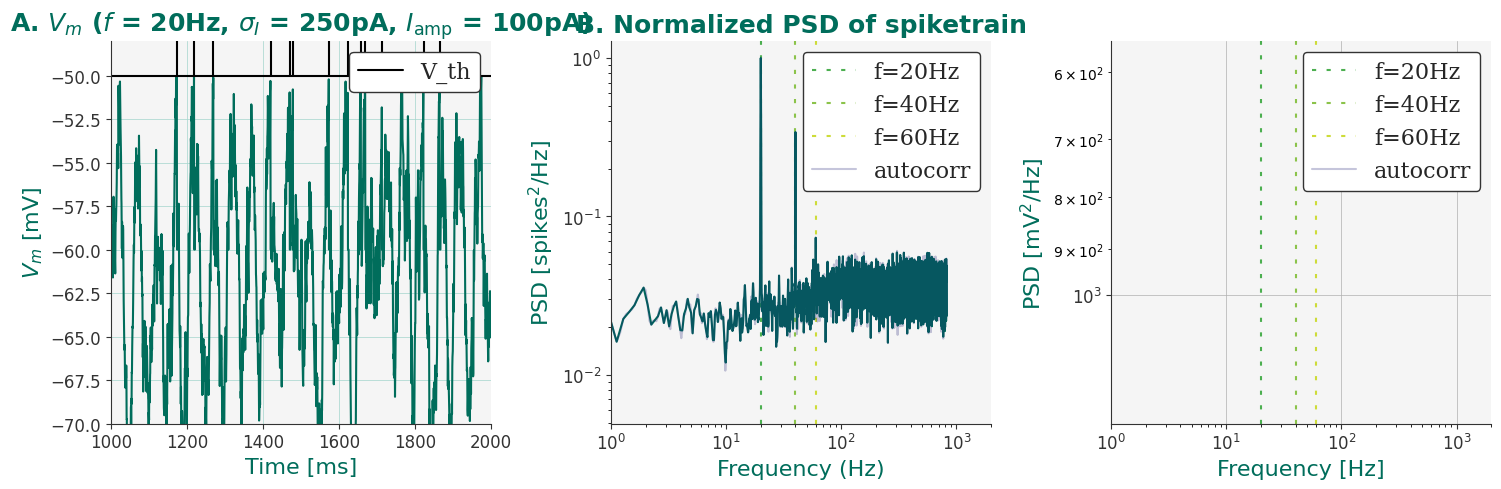

In [5]:
# fig 1 - welch autocorr
plot_results(sim_time=100e3,a_values=[100],f_values=[20], SD_values=[250],
             noisy=True, xLim=1, seed=2, 
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
                welch=True, demean=True, normalize=True)


Apr 01 09:52:13 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 01 09:52:13 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
dt 0.00025
fs: 4000.0
entered block


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s),SNR (autocorr),f at max (autocorr)
0,20,100,-50.000966,5.186622,3.880900e+09,2.641897e+09,0.0,899.9,2935753.55,9.85,620.74163,0.0


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_82.png


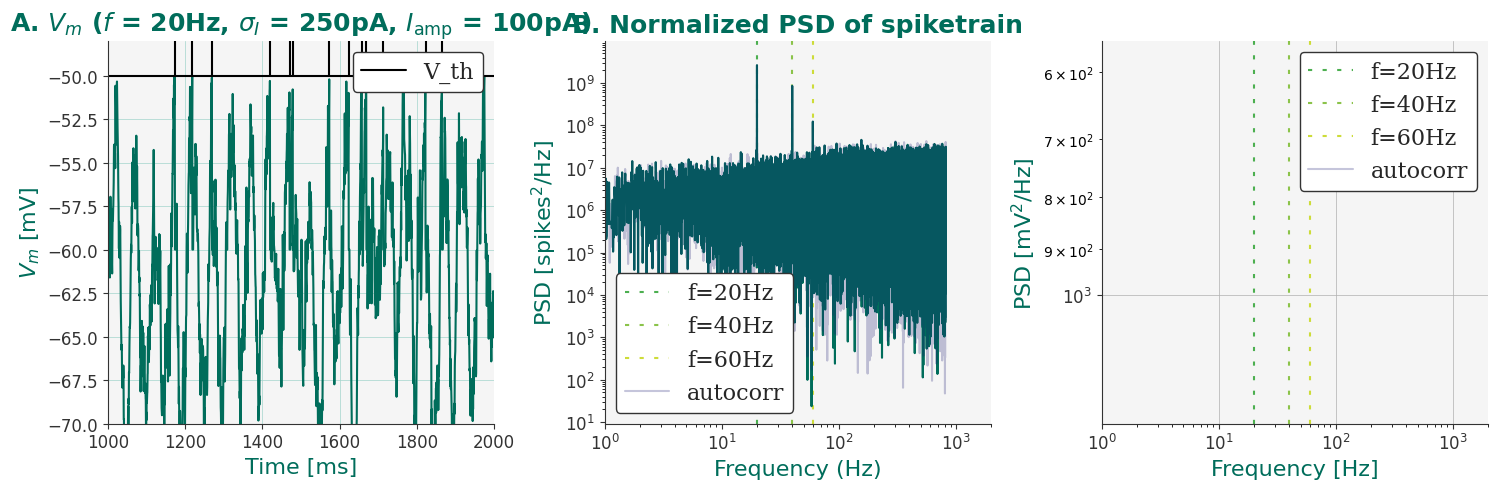

In [5]:
# fig 1 - vanlig psd autocorr
plot_results(sim_time=100e3,a_values=[100],f_values=[20], SD_values=[250],
             noisy=True, xLim=1, seed=2, 
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
                welch=False, demean=False, normalize=False)

,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,1000,1000,-50.003135,3.881304,90.58,90.58,1000.0,9.7,9.34,4.32


Saved plot as: /home/tonje/master/TIS/results/main_38.png


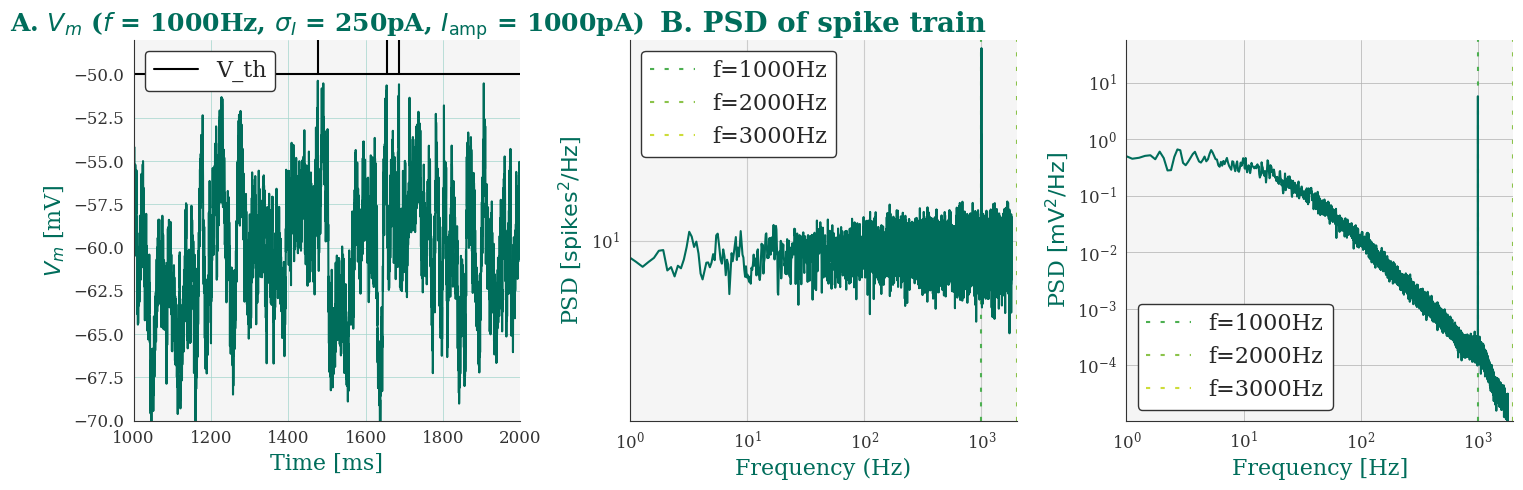

In [ ]:
# fig 2 
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], SD_values=[250],
             noisy=True, xLim=1, seed=2,
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=False, 
                normalize_psd=False)


Apr 02 13:17:34 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 02 13:17:34 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
dt 0.00025
fs: 4000.0
entered block


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s),SNR (autocorr),f at max (autocorr)
0,1000,1000,-50.003135,3.881304,746496000.0,383248000.0,0.0,231.15,1658024.63,4.32,195.907919,0.0


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_83.png


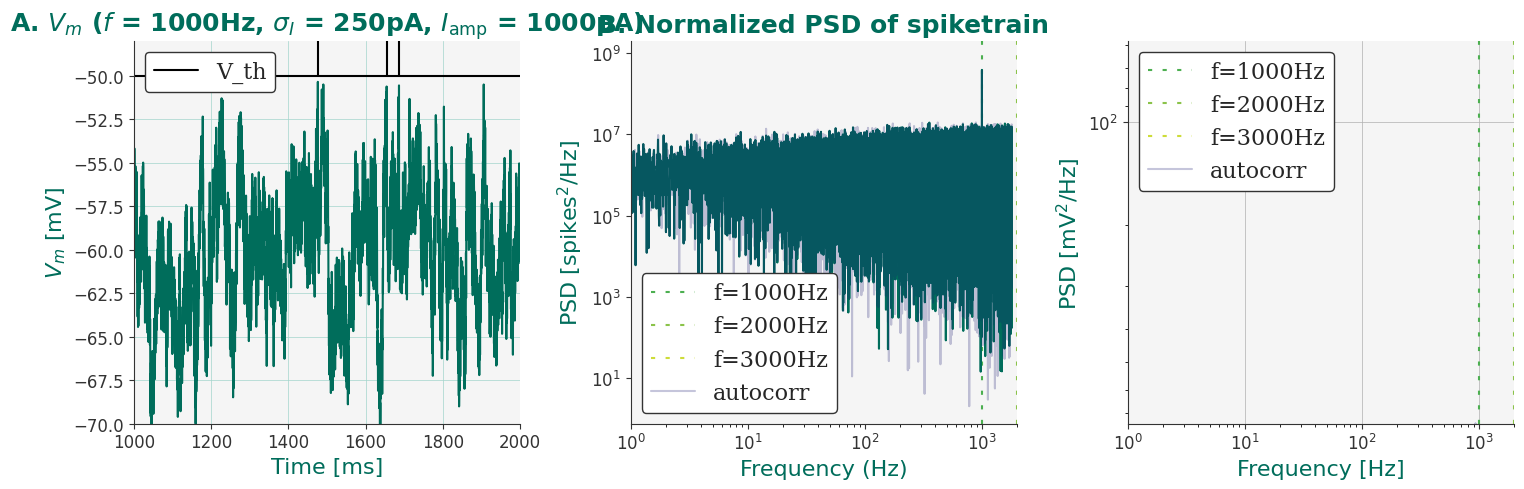

In [ ]:
# fig 2 - autocorr
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], SD_values=[250],
             noisy=True, xLim=1, seed=2, 
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
                welch=False, demean=False, normalize=False)

psd values [0.01402193 0.06121562 0.09436893 ... 0.08730419 0.10441803 0.0887403 ]
autocorr psd values [0.02837412 0.03863461 0.0619312  ... 0.09432407 0.08710177 0.08622961]
entered block


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s),SNR (autocorr),f at max (autocorr)
0,1000,1000,-50.003135,3.881304,1.0,1.0,1000.0,9.7,0.1,4.32,8.956069,1000.02


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_84.png


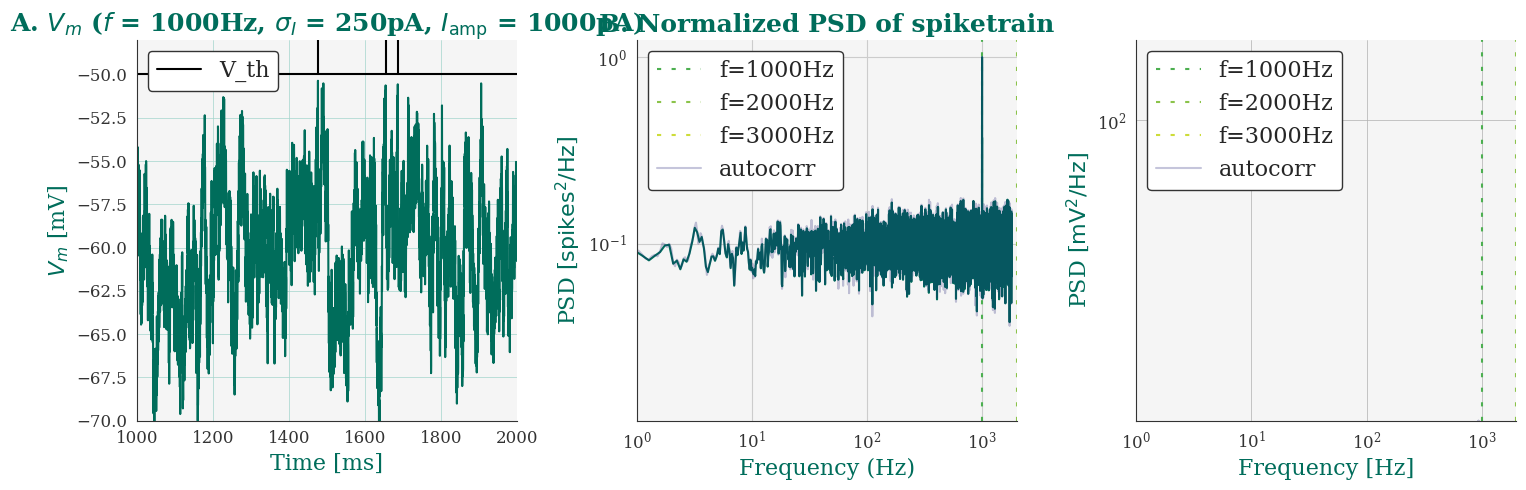

In [ ]:
# fig 2 - autocorr welch
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], SD_values=[250],
             noisy=True, xLim=1, seed=2, 
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
                welch=True, demean=True, normalize=True)


Apr 08 09:15:23 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 08 09:15:23 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
len spike rate 400000
psd values [1.27006712 5.54473733 8.54767064 ... 7.90776612 9.45788961 8.03784555]
autocorr psd values [0.47630099 0.6485384  1.0396056  ... 1.58336739 1.46213052 1.44748991]
entered block


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s),SNR (autocorr),f at max (autocorr)
0,1000,1000,-50.003135,3.881304,90.58,90.58,1000.0,9.7,9.34,4.32,8.956069,1000.02


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_89.png


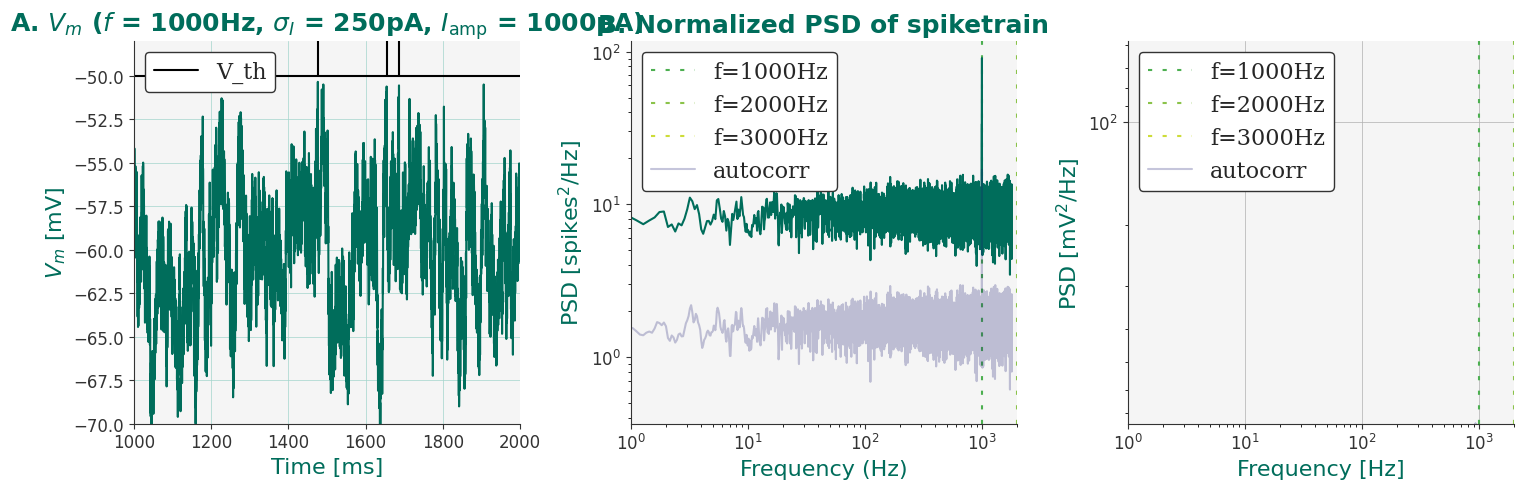

In [6]:
# fig 2 - autocorr welch uten normalisering
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], SD_values=[250],
             noisy=True, xLim=1, seed=2, 
             bin_size=0.25, second_sine=False, harmonics=3,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
                welch=True, demean=True, normalize=False)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[1000, 1020]",20,1000,-50.00093,4.00626,178.29,143.05,1.83,1020.0,11.87,12.06,6.13,3.0,12.1


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[1020, 1040]",20,1000,-50.000559,4.0,175.67,175.67,2.33,1020.0,13.6,12.91,6.19,3.5,12.9


Saved plot as: /home/tonje/master/TIS/results/main_35.png


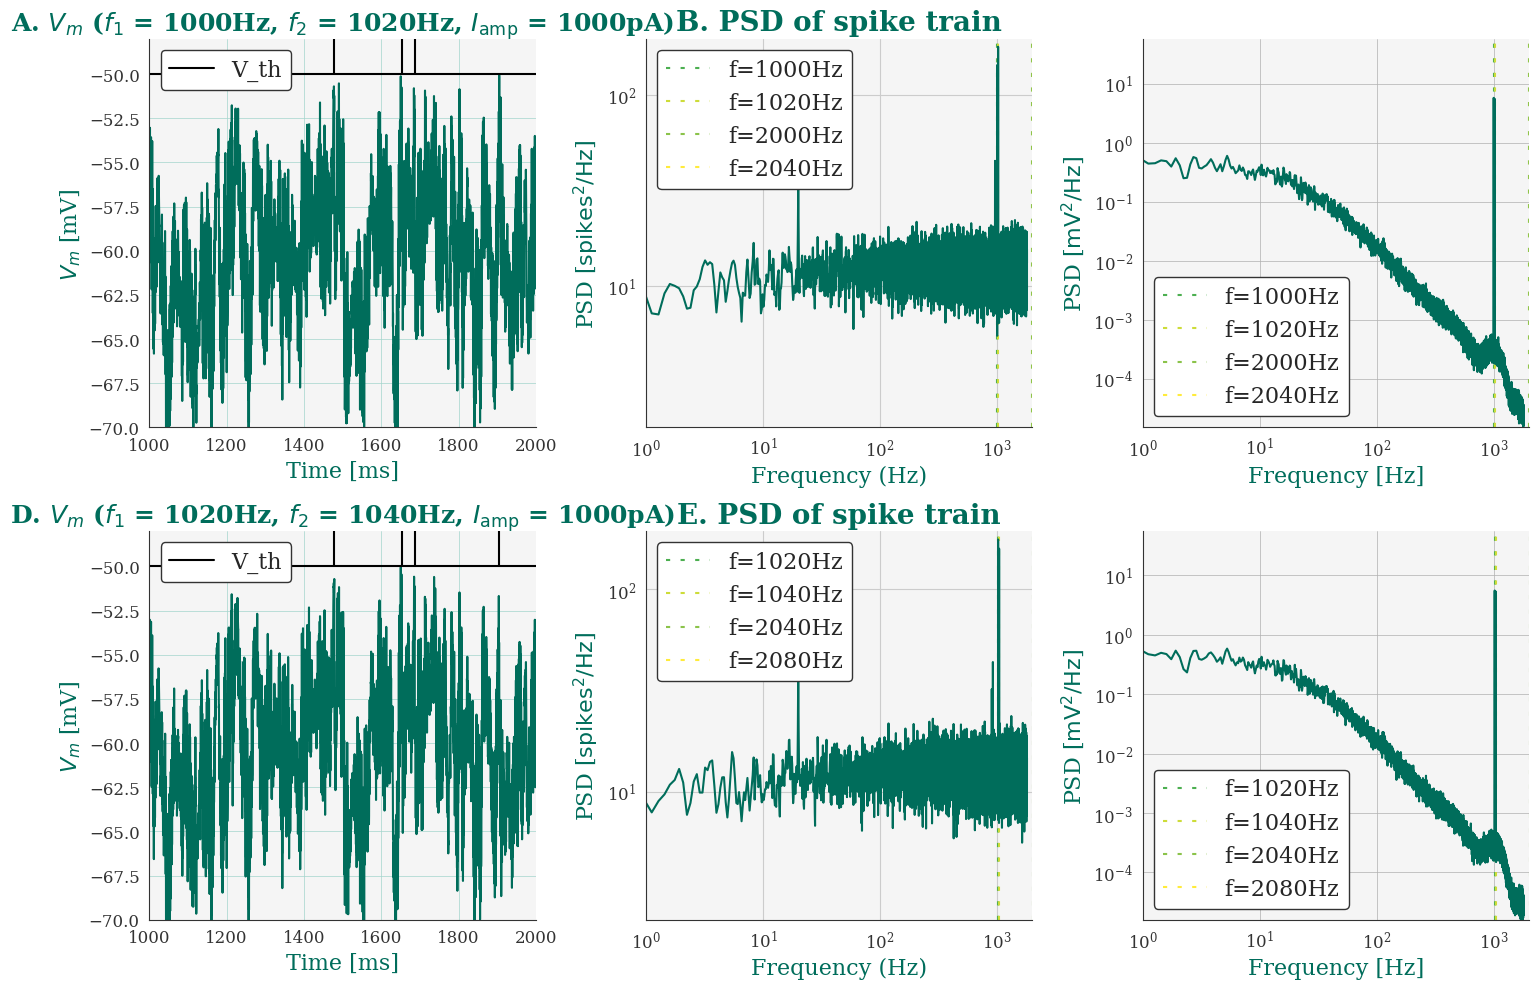

In [ ]:
# fig 3 - PSD 
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000, 1020], SD_values=[250],
             noisy=True, xLim=1, seed=2,
             bin_size=0.25, second_sine=True, harmonics=2,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=False, 
                normalize_psd=False)

dt 0.00025
fs: 4000.0
entered block


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),SNR (autocorr),f at max (autocorr)
0,"[1000, 1020]",20,1000,-50.00093,4.00626,1.503076e+09,618228000.0,1.503076e+09,0.0,289.72,2133907.79,6.13,51.6,2133907.8,238.50992,0.0


len vm auto values 179999
len freqqs auto 179999
dt 0.00025
fs: 4000.0
entered block


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),SNR (autocorr),f at max (autocorr)
0,"[1020, 1040]",20,1000,-50.000559,4.0,1.532644e+09,773464814.7,1.532644e+09,0.0,346.05,2235133.15,6.19,69.1,2235133.1,276.197769,0.0


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_86.png


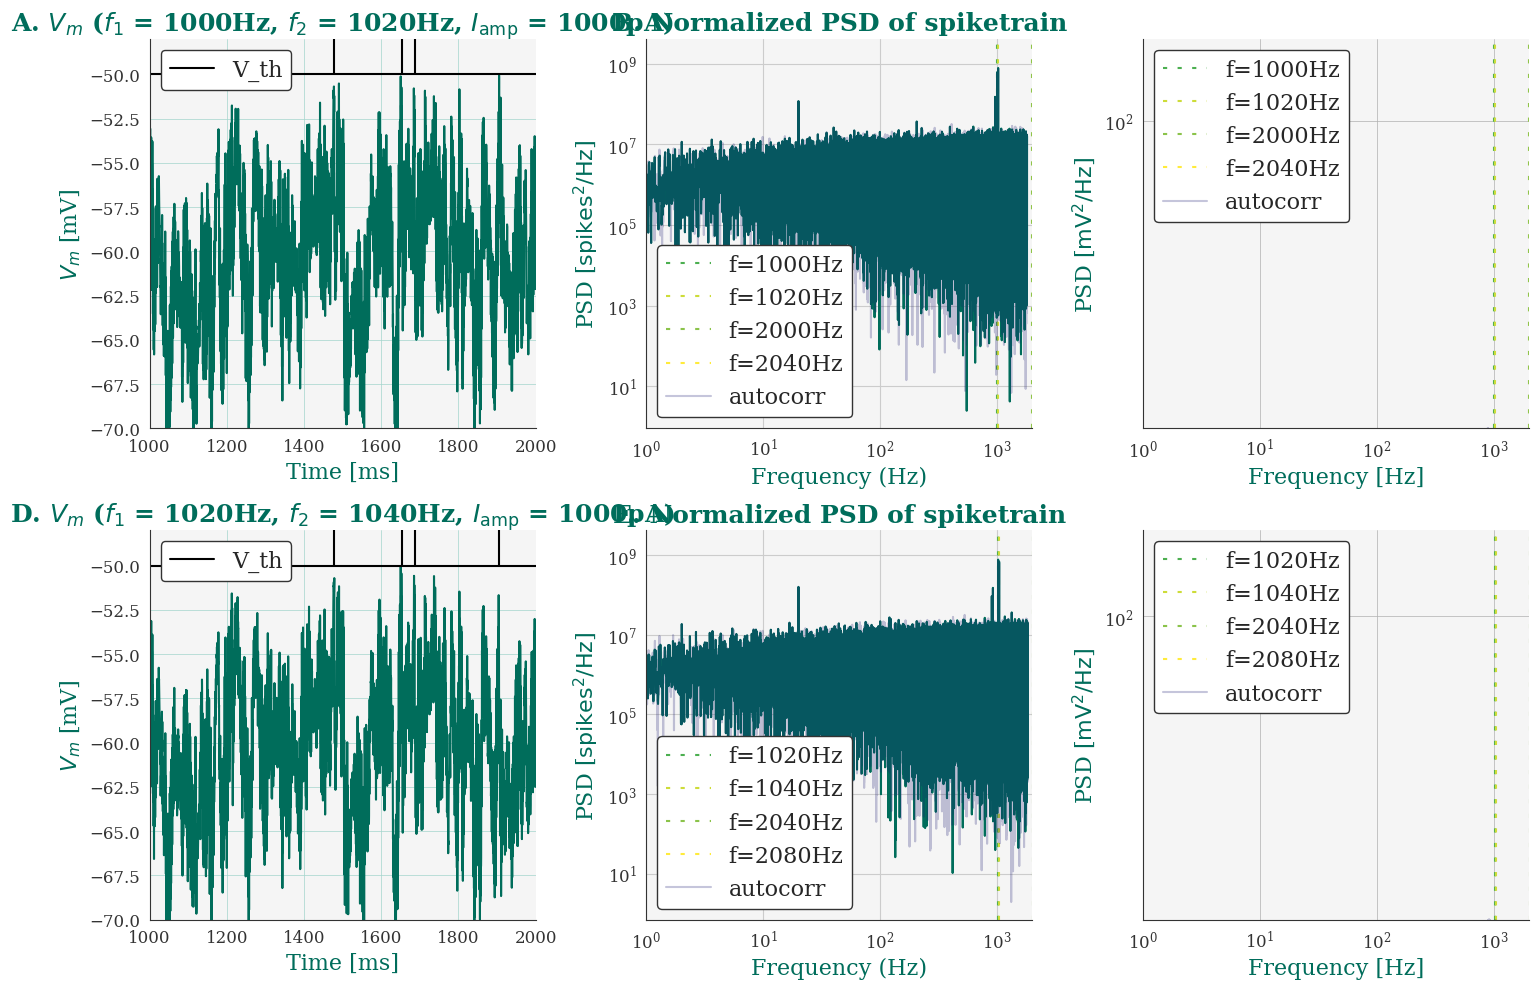

In [11]:
# fig 3 - PSD of autocorrelation
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000, 1020], SD_values=[250],
             noisy=True, xLim=1, seed=2,
             bin_size=0.25, second_sine=True, harmonics=2,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
            welch=False, demean=False, normalize=False)

psd values [0.01028507 0.04279307 0.05465198 ... 0.07378209 0.06574256 0.07440324]
autocorr psd values [0.02096219 0.02924774 0.04360703 ... 0.06753551 0.08272979 0.08876019]
entered block


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),SNR (autocorr),f at max (autocorr)
0,"[1000, 1020]",20,1000,-50.00093,4.00626,1.0,0.8,0.01,1020.0,11.87,0.07,6.13,3.0,0.1,10.672697,1020.0204


len vm auto values 179999
len freqqs auto 179999
psd values [0.01327512 0.05080255 0.06498268 ... 0.06797562 0.06345741 0.06141892]
autocorr psd values [0.02715694 0.03601975 0.05196211 ... 0.06265671 0.06190962 0.0551593 ]
entered block


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),SNR (autocorr),f at max (autocorr)
0,"[1020, 1040]",20,1000,-50.000559,4.0,1.0,1.0,0.01,1020.0,13.6,0.07,6.19,3.5,0.1,12.031543,1020.0204


len vm auto values 179999
len freqqs auto 179999
Saved plot as: /home/tonje/master/TIS/results/main_85.png


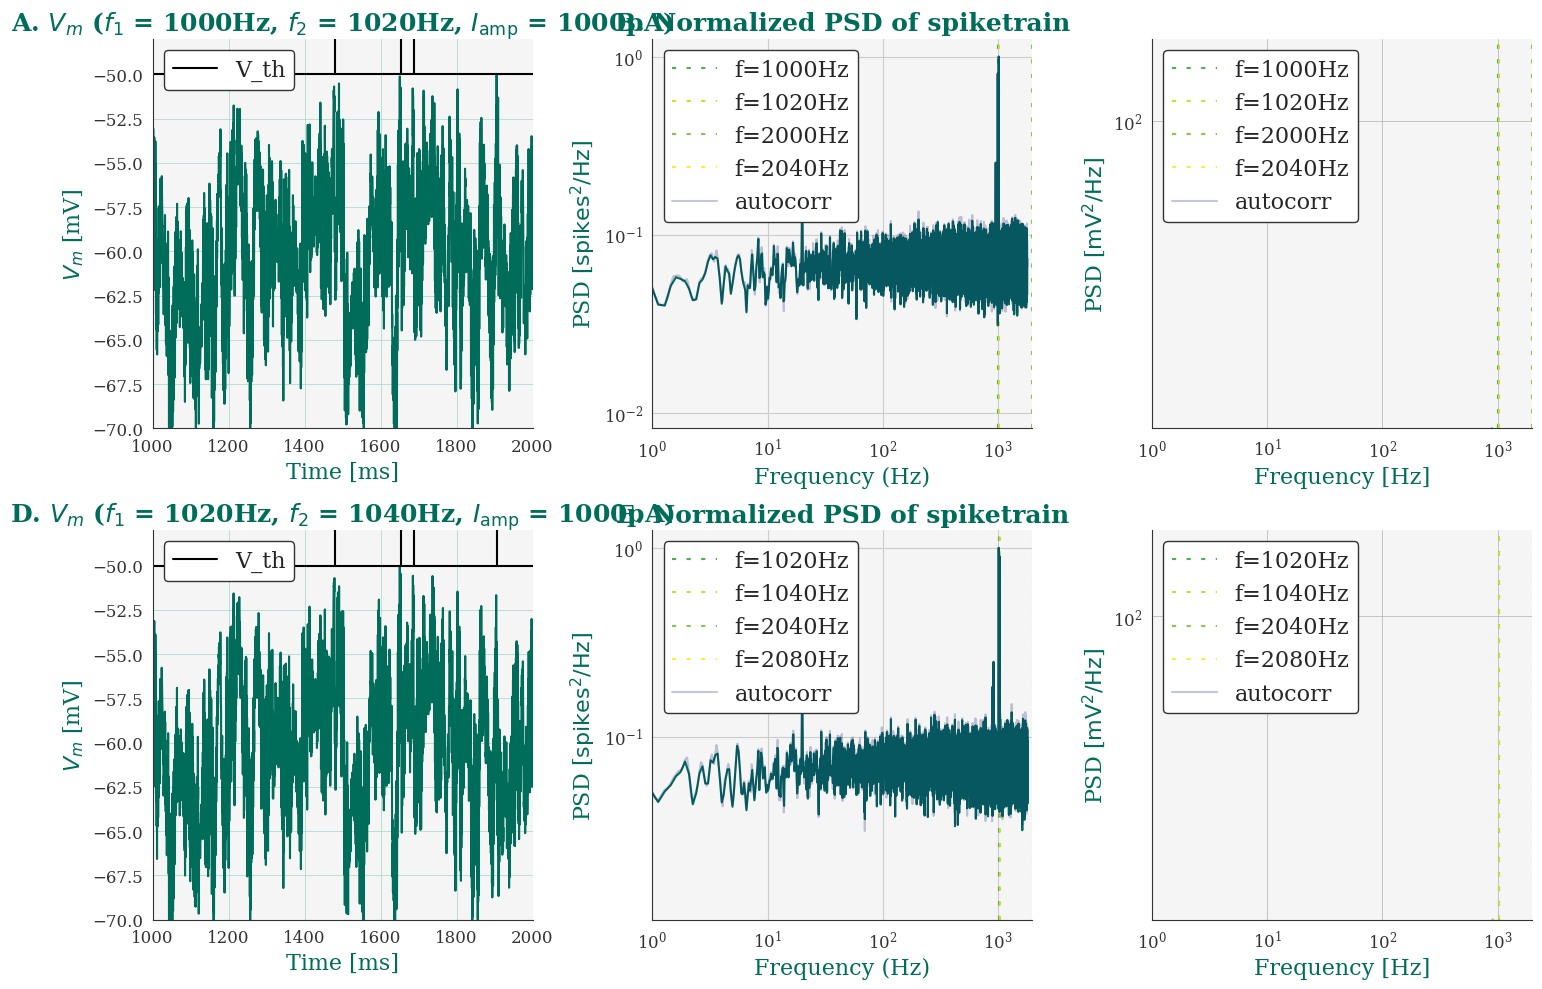

In [10]:
# fig 3 - PSD of autocorrelation with welch
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000, 1020], SD_values=[250],
             noisy=True, xLim=1, seed=2,
             bin_size=0.25, second_sine=True, harmonics=2,
            save_fig=True, resolution=0.25, y_min=1e-16, autocorr_validation=True, 
            welch=True, demean=True, normalize=True)

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_56.png


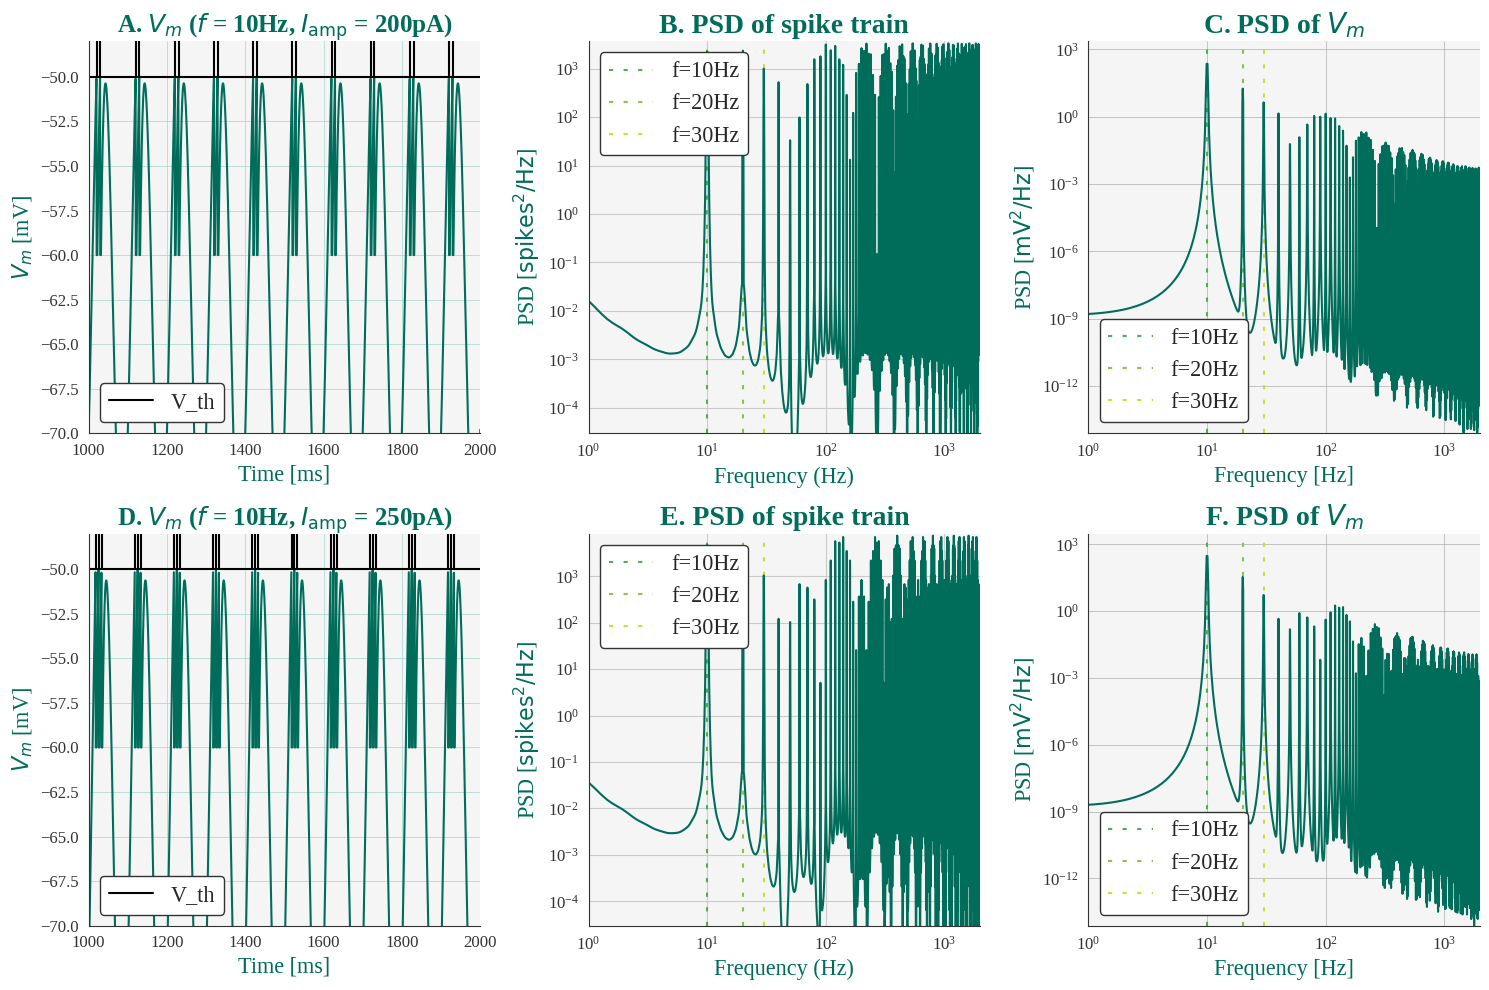

In [41]:
plot_results(sim_time=100e3,
             a_values=[200,250],SD_values=[250], f_values=[10], 
             noisy=False, xLim=1, seed=2, bin_size=0.25, second_sine=False,
             harmonics=3,save_fig=True, resolution=0.25, y_min=1e-16)

In [42]:
find_I(-51e-3, 1000)

I_amp for f=1000: 5655.6pA


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max PSD Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,100,100,-50.003088,3.831704,38.09,38.09,100.0,5.74,6.64,3.16


Saved plot as: /home/tonje/master/TIS/results/main_3.png


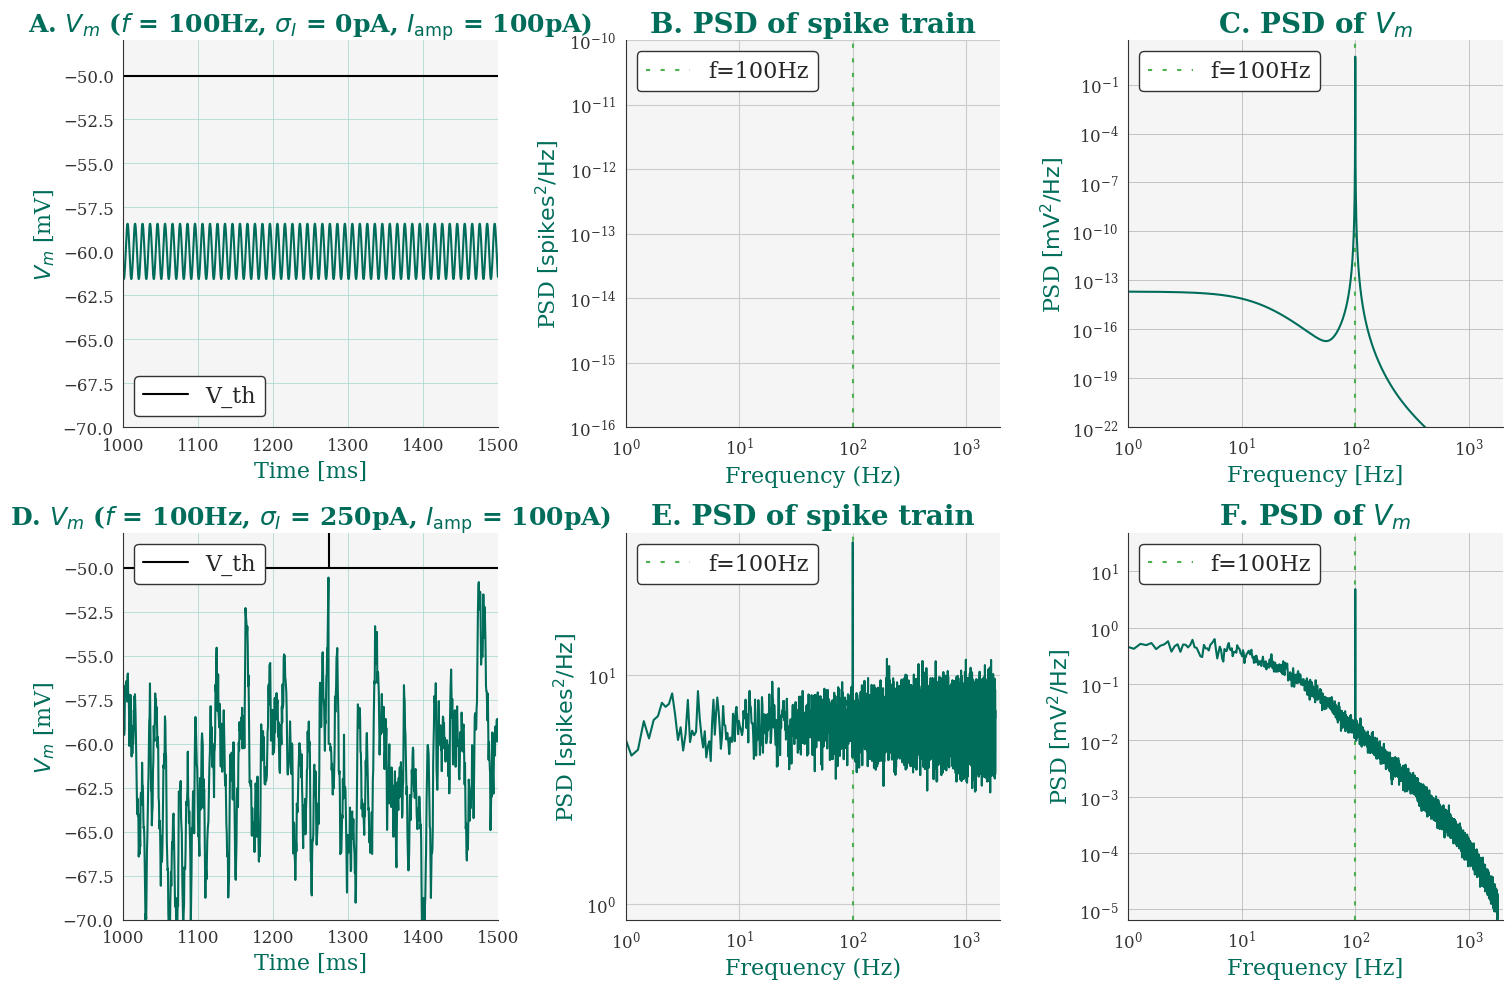

In [21]:
plot_results(sim_time=100000,save_fig=True,
             a_values=[100],f_values=[100], SD_values=[0,250],
             noisy=True, seed=42, bin_size=0.25, second_sine=False, 
             resolution=0.25, xLim=0.5, y_min=1e-22)

,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],FFT Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,100,100,-50.003088,38.09,38.09,100.0,5.74,6.64,3.16


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_67.png


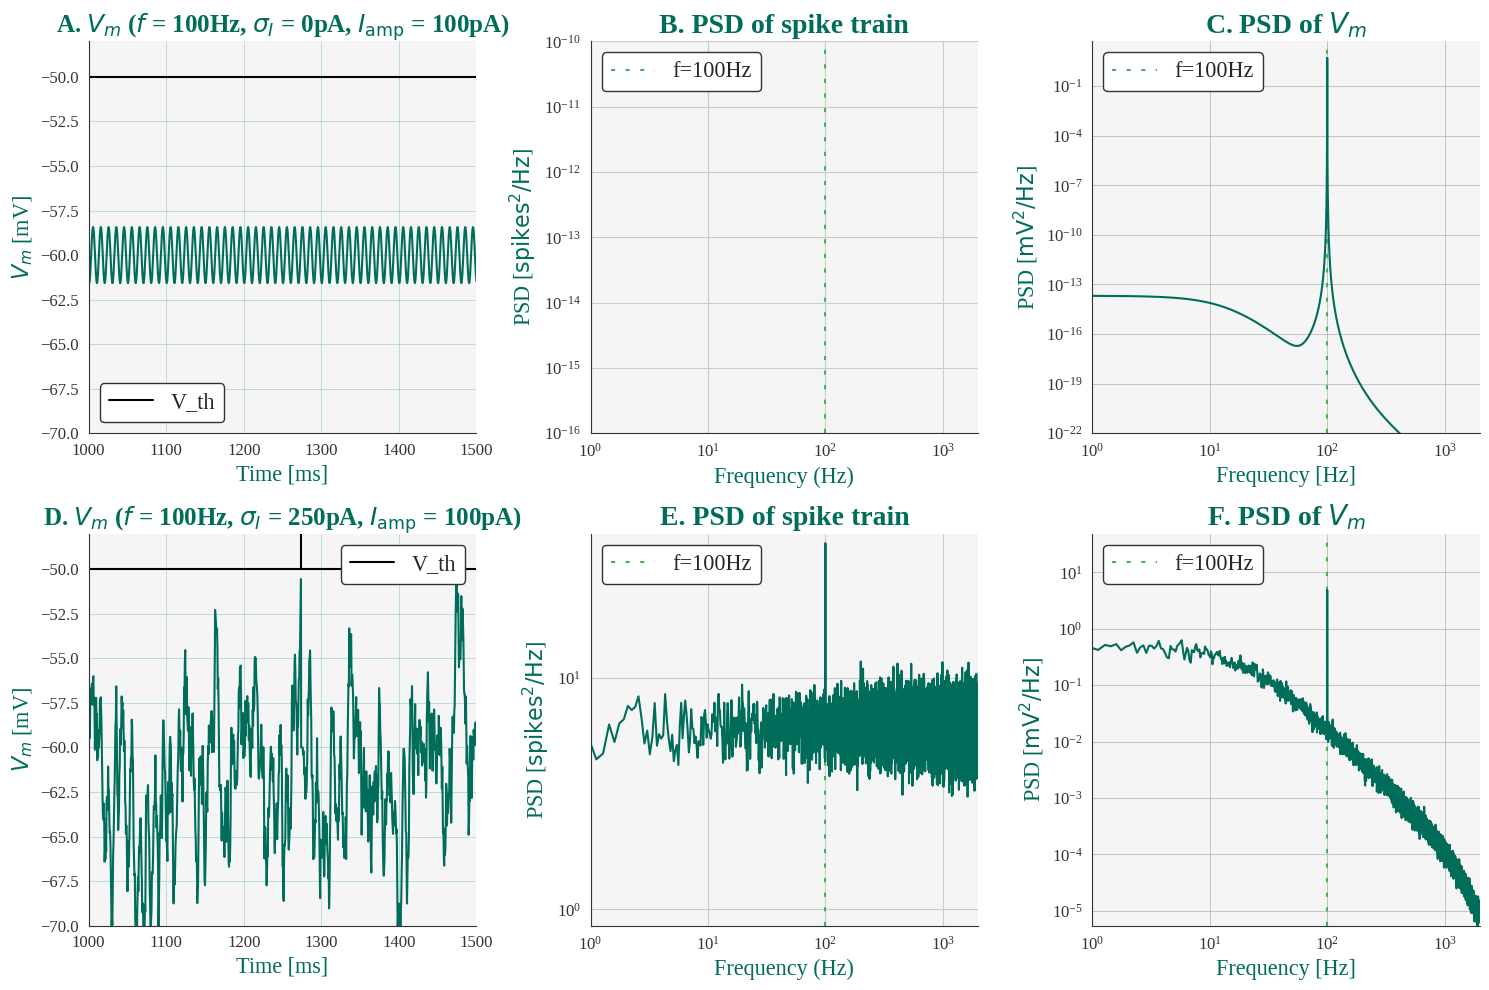

In [10]:
plot_results(sim_time=100000,save_fig=True,
             a_values=[100],f_values=[100], SD_values=[0,250],
             noisy=True, seed=42, bin_size=0.25, second_sine=False, 
             resolution=0.25, xLim=0.5, y_min=1e-22)

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_58.png


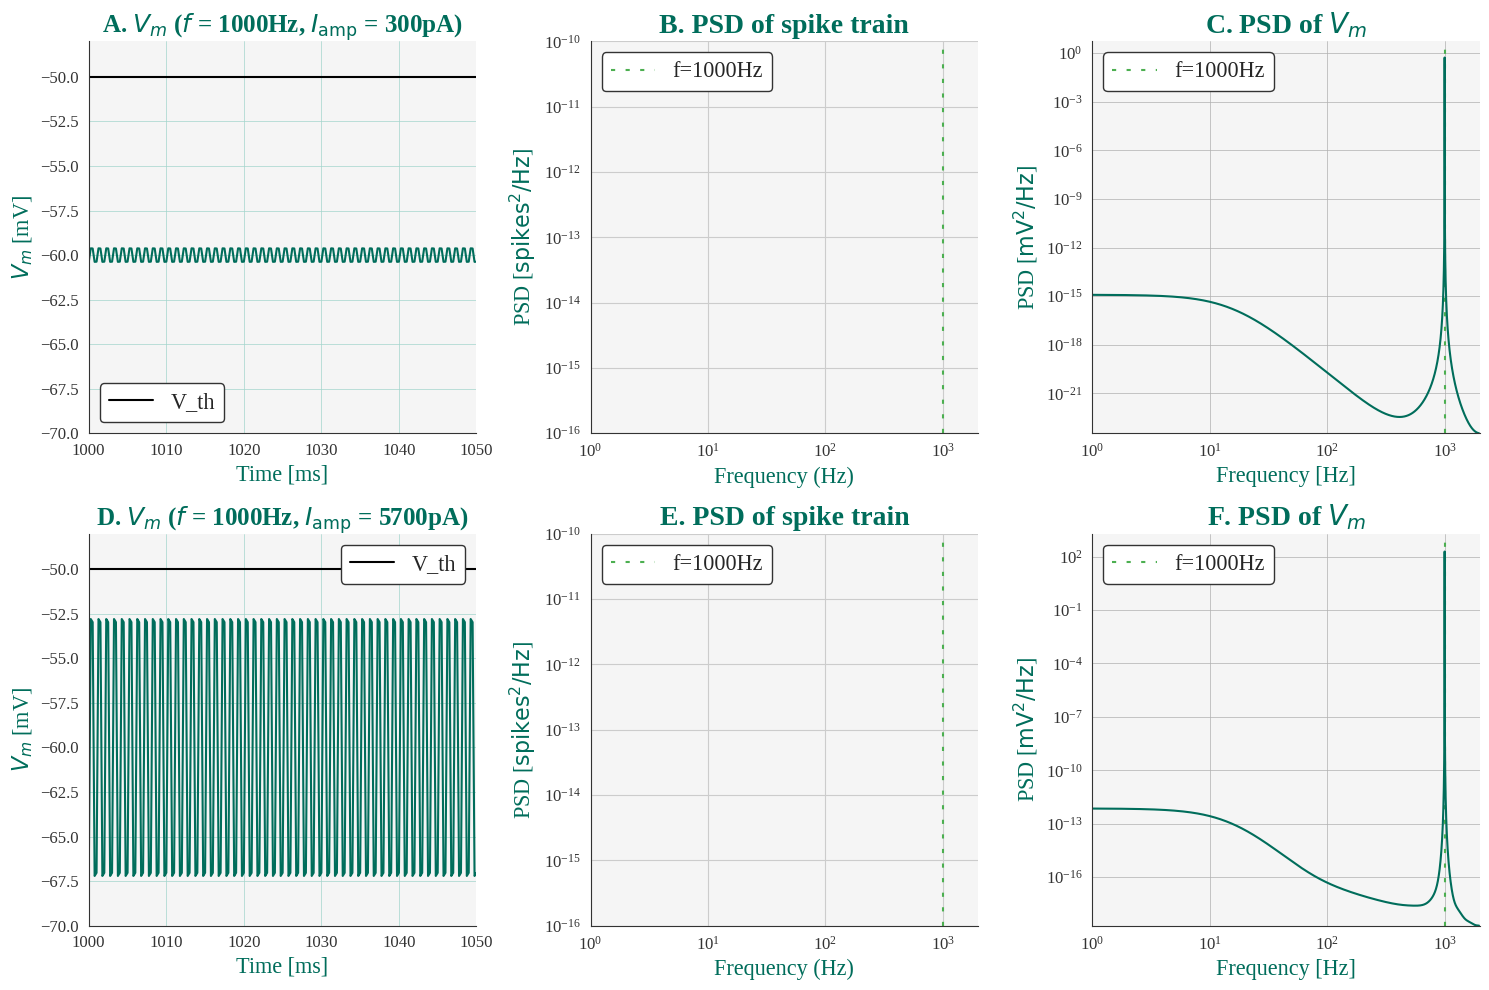

In [44]:
plot_results(sim_time=100e3, SD_values=[0],
             a_values=[300,5700],f_values=[1000],
             noisy=False, xLim=0.05, seed=42, bin_size=0.25, second_sine=False, 
            harmonics=1, save_fig=True, log=True, resolution=0.25, y_min=1e-24)

,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],FFT Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,1000,100,-50.000156,9.2,6.71,58.4,1.3,5.15,2.49


,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],FFT Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,1000,300,-50.000061,14.67,14.67,1000.0,2.71,5.42,2.6


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_59.png


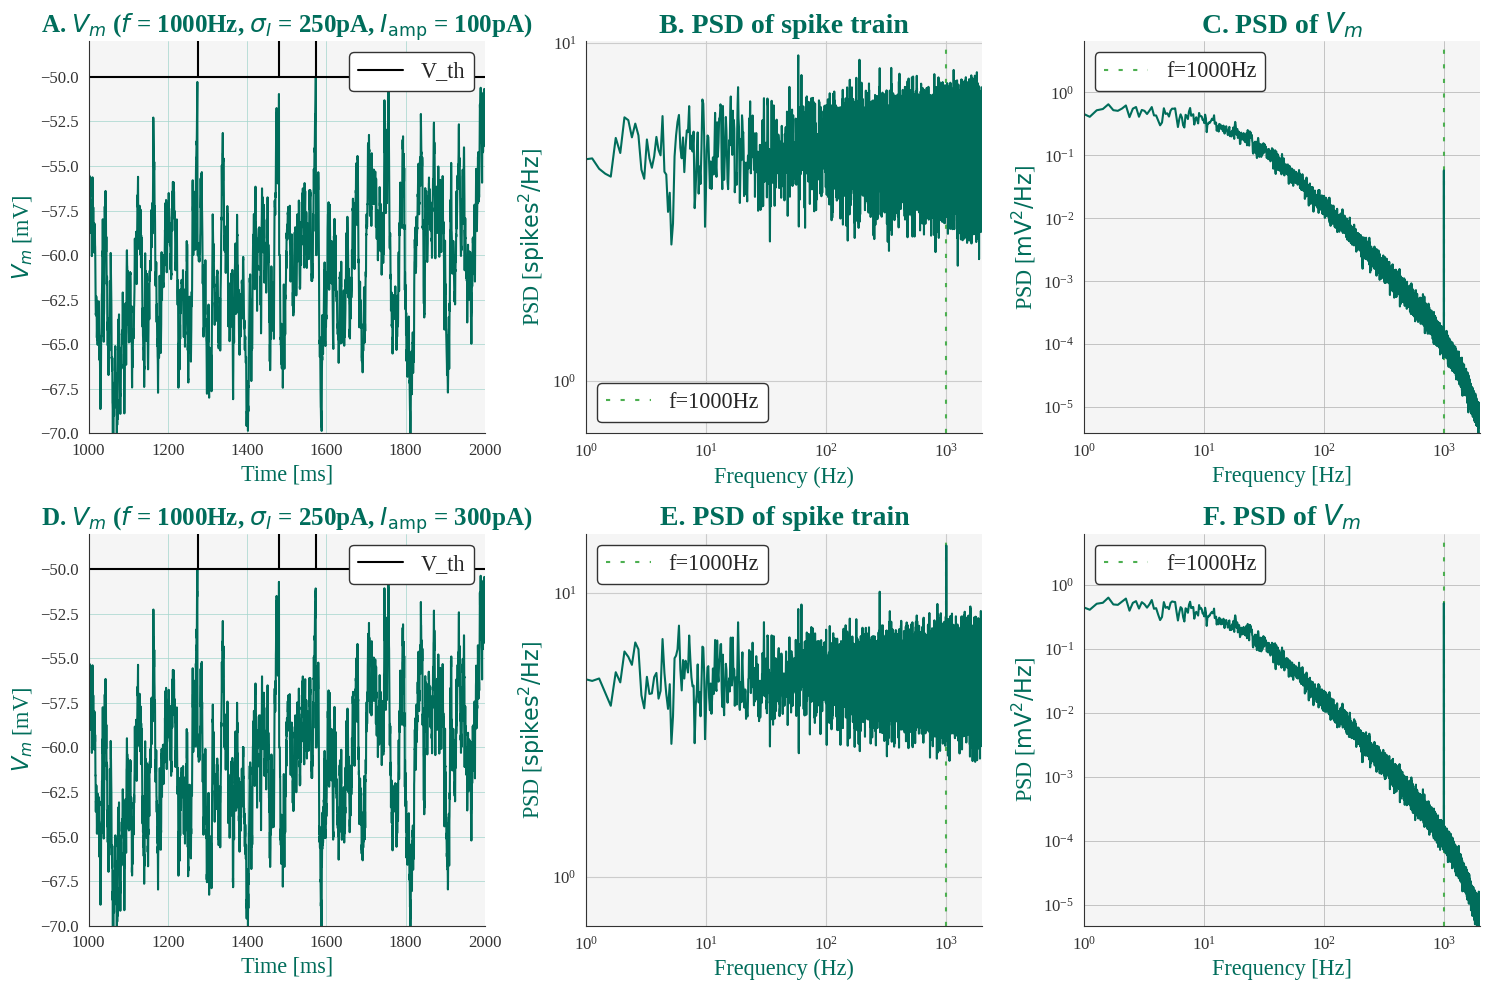

In [46]:
plot_results(sim_time=100e3, SD_values=[250],
             a_values=[100,300],f_values=[1000],
             noisy=True, xLim=1, seed=42, bin_size=0.25, second_sine=False, 
            harmonics=1, save_fig=True, resolution=0.25, y_min=1e-16)

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_60.png


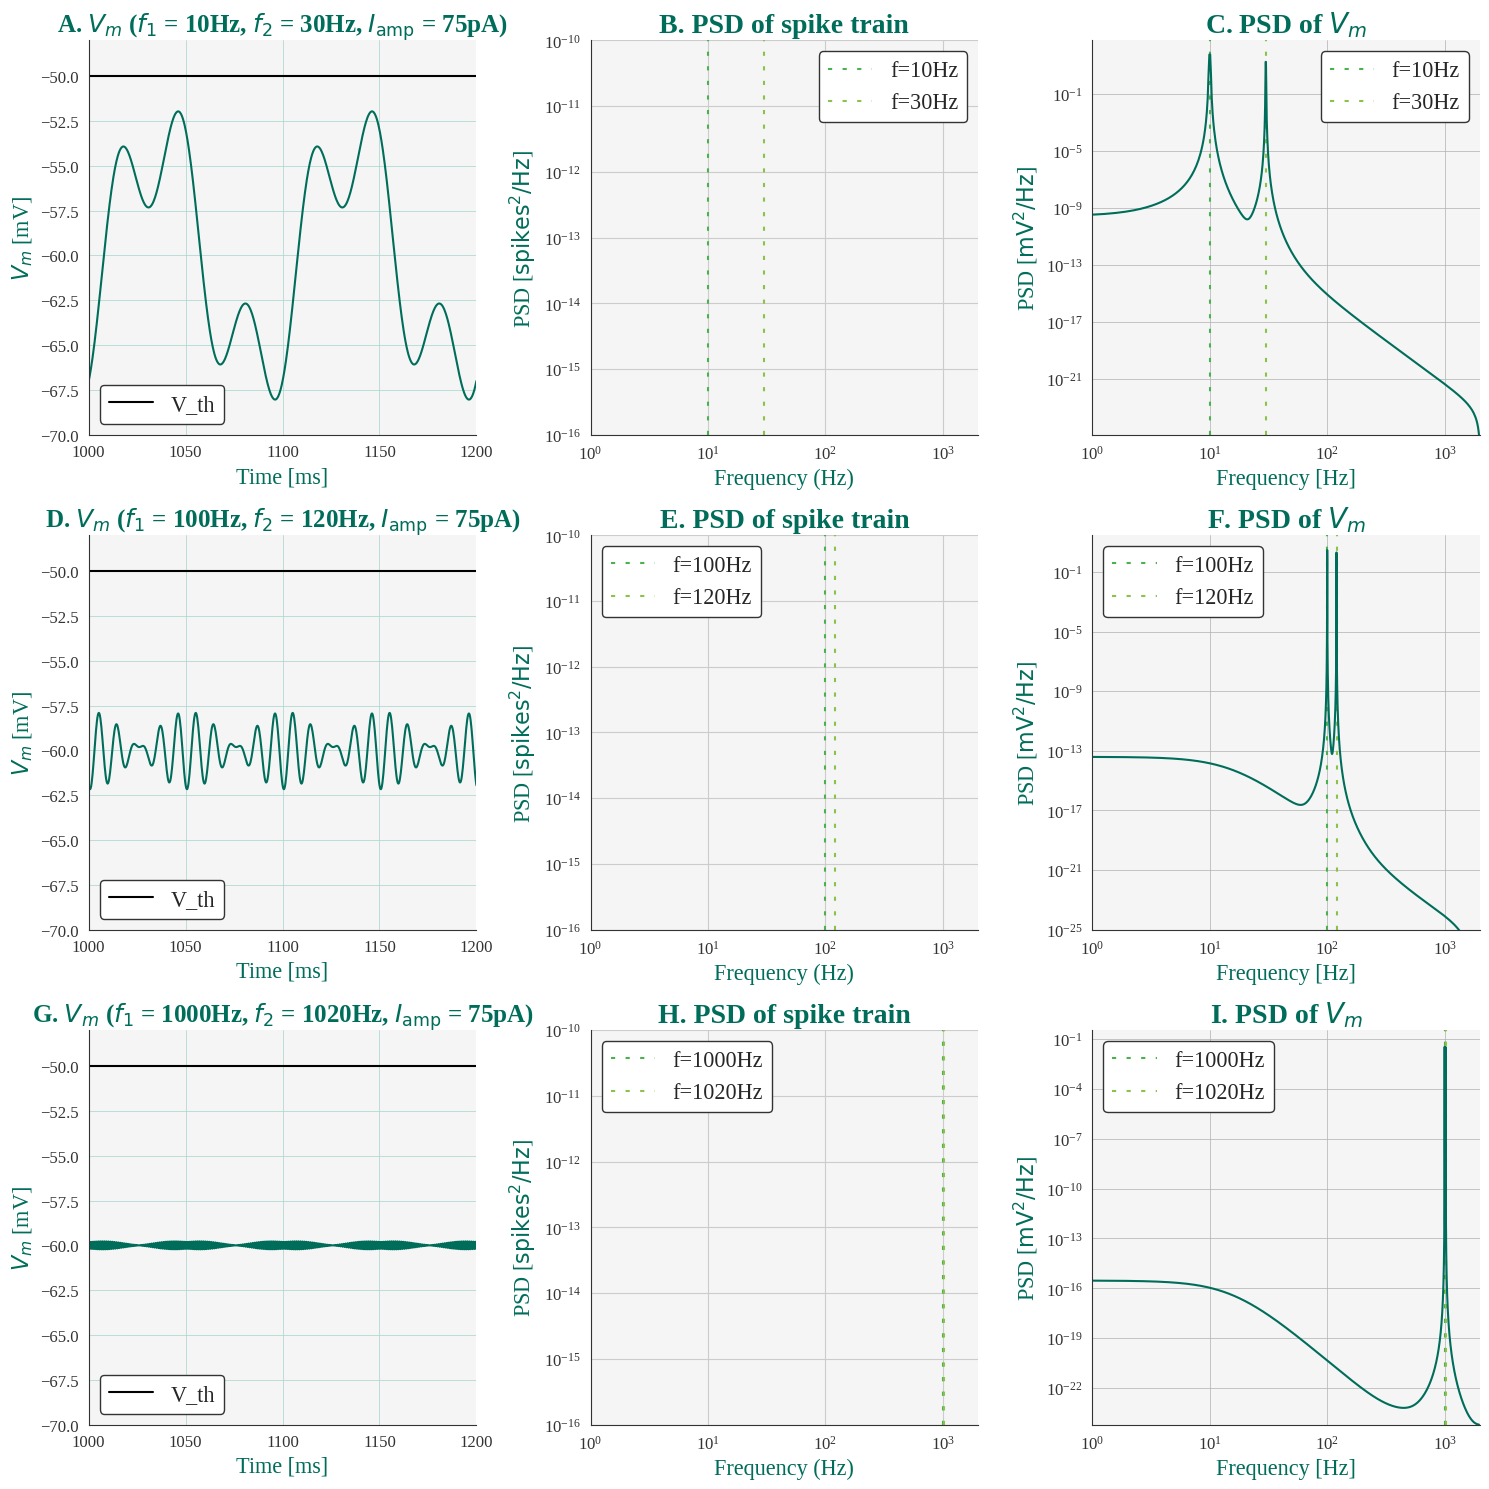

In [47]:
"""Dobbel sinus uten noise """
plot_results(sim_time=100e3,a_values=[75], f_values=[10,100,1000], noisy=False,
             second_sine=True, beat=20, xLim=0.2, seed=42, harmonics=1, psd_segments=16,
             bin_size=0.25, resolution=0.25,  save_fig=True, y_min=1e-25)

Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_61.png


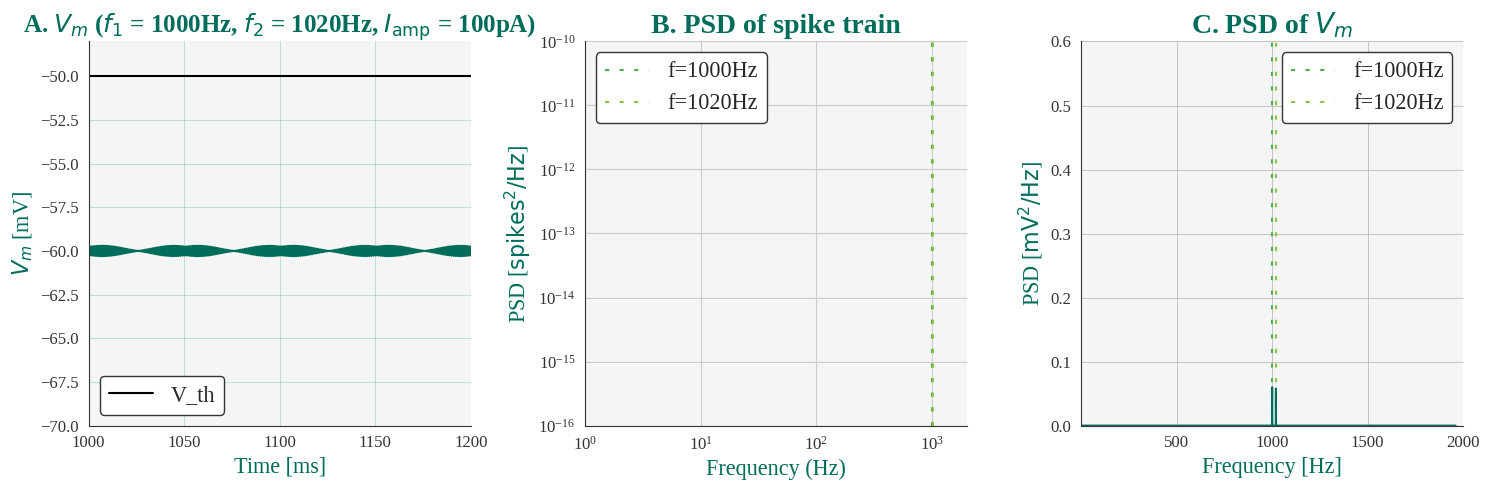

In [48]:
""" to make sure there are two and not only one peak"""
plot_results(sim_time=100e3,a_values=[100], f_values=[1000], noisy=False, log=False,
             second_sine=True, beat=20, xLim=0.2, seed=42, harmonics=1, psd_segments=16,
             bin_size=0.25, resolution=0.25, save_fig=True, y_min=1e-16)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[10, 30]",20,100,-50.000036,722.17,719.25,78.05,10.08,27.88,25.8,16.25,4.9,15.9


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_62.png


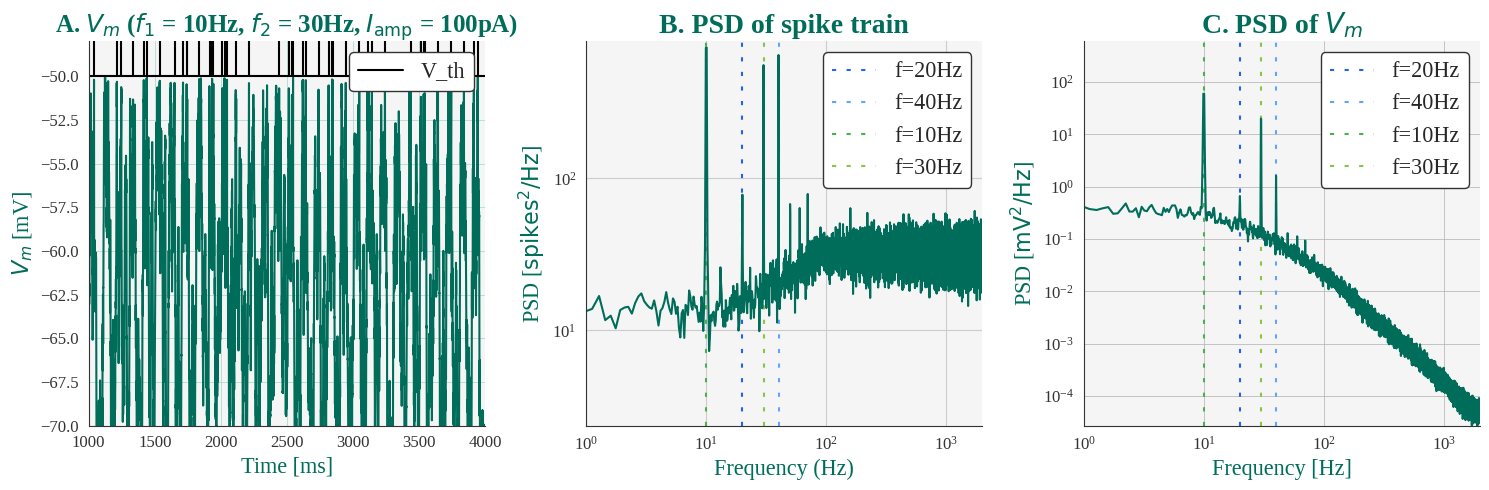

In [54]:
plot_results(sim_time=100e3, SD_values=[250],
             a_values=[100], f_values=[10], second_sine=True, beat=20, psd_segments=16,
             noisy=True, xLim=3, seed=42, bin_size=0.25, resolution=0.25, harmonics_beat=2, save_fig=True)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[100, 120]",20,100,-50.001332,49.33,49.33,14.51,100.0,6.17,8.0,3.92,2.0,7.4


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_63.png


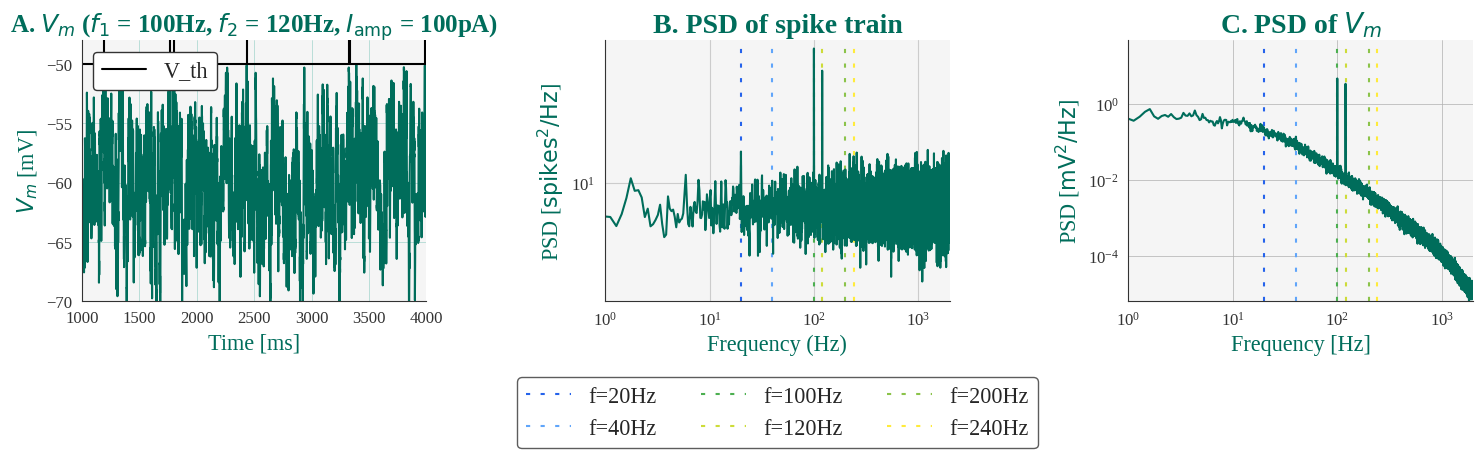

In [56]:
plot_results(sim_time=100e3, SD_values=[250], legend=True,
             a_values=[100], f_values=[100], second_sine=True, beat=20, psd_segments=16, harmonics=2,
             noisy=True, xLim=3, seed=100, bin_size=0.25, resolution=0.25, harmonics_beat=2, save_fig=True)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[1000, 1020]",20,500,-50.000758,49.05,36.66,12.86,1020.0,5.14,7.13,3.65,1.8,7.1


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat)
0,"[1000, 1020]",20,1000,-50.000394,164.94,134.82,41.29,1020.0,11.33,11.9,5.94,3.7,11.1


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/main_64.png


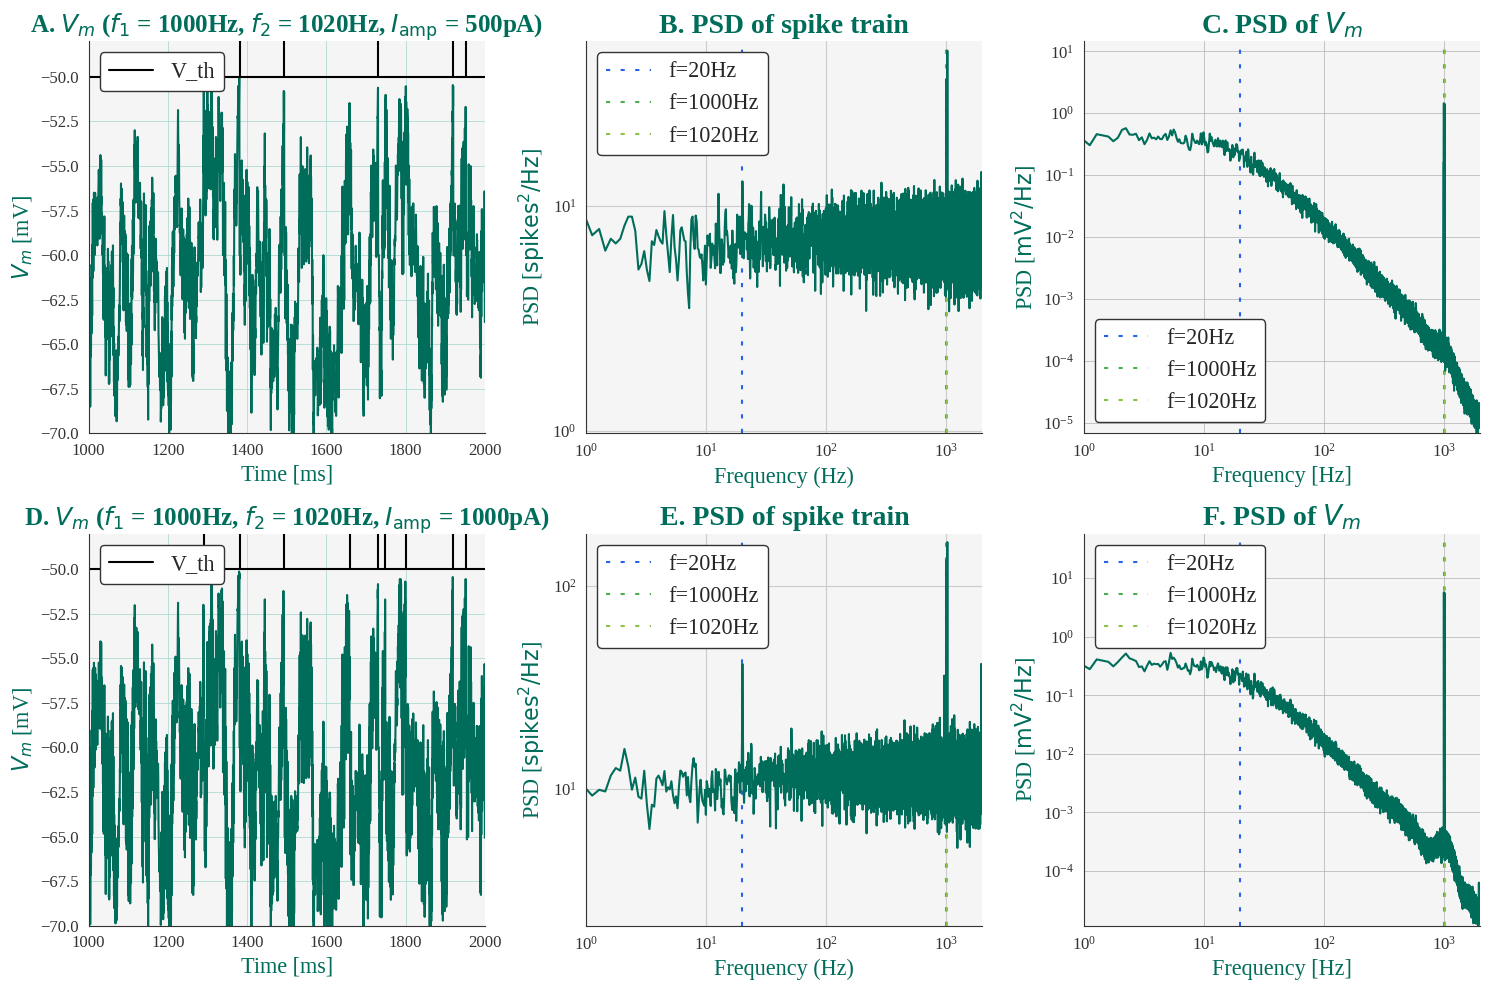

In [57]:
plot_results(sim_time=100e3, SD_values=[250],
             a_values=[500,1000], f_values=[1000], second_sine=True, beat=20, y_min=5e-10, harmonics=1,
             noisy=True, xLim=True, seed=281532, bin_size=0.25, resolution=0.25, harmonics_beat=1, save_fig=True)

,Input Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],FFT Amplitude for f [(spikes pr sec)/Hz],Frequency at max (Hz),SNR,noise average,Spike Rate (spikes/s)
0,10,100,-50.00199,134.88,123.24,20.0,16.39,7.52,4.58


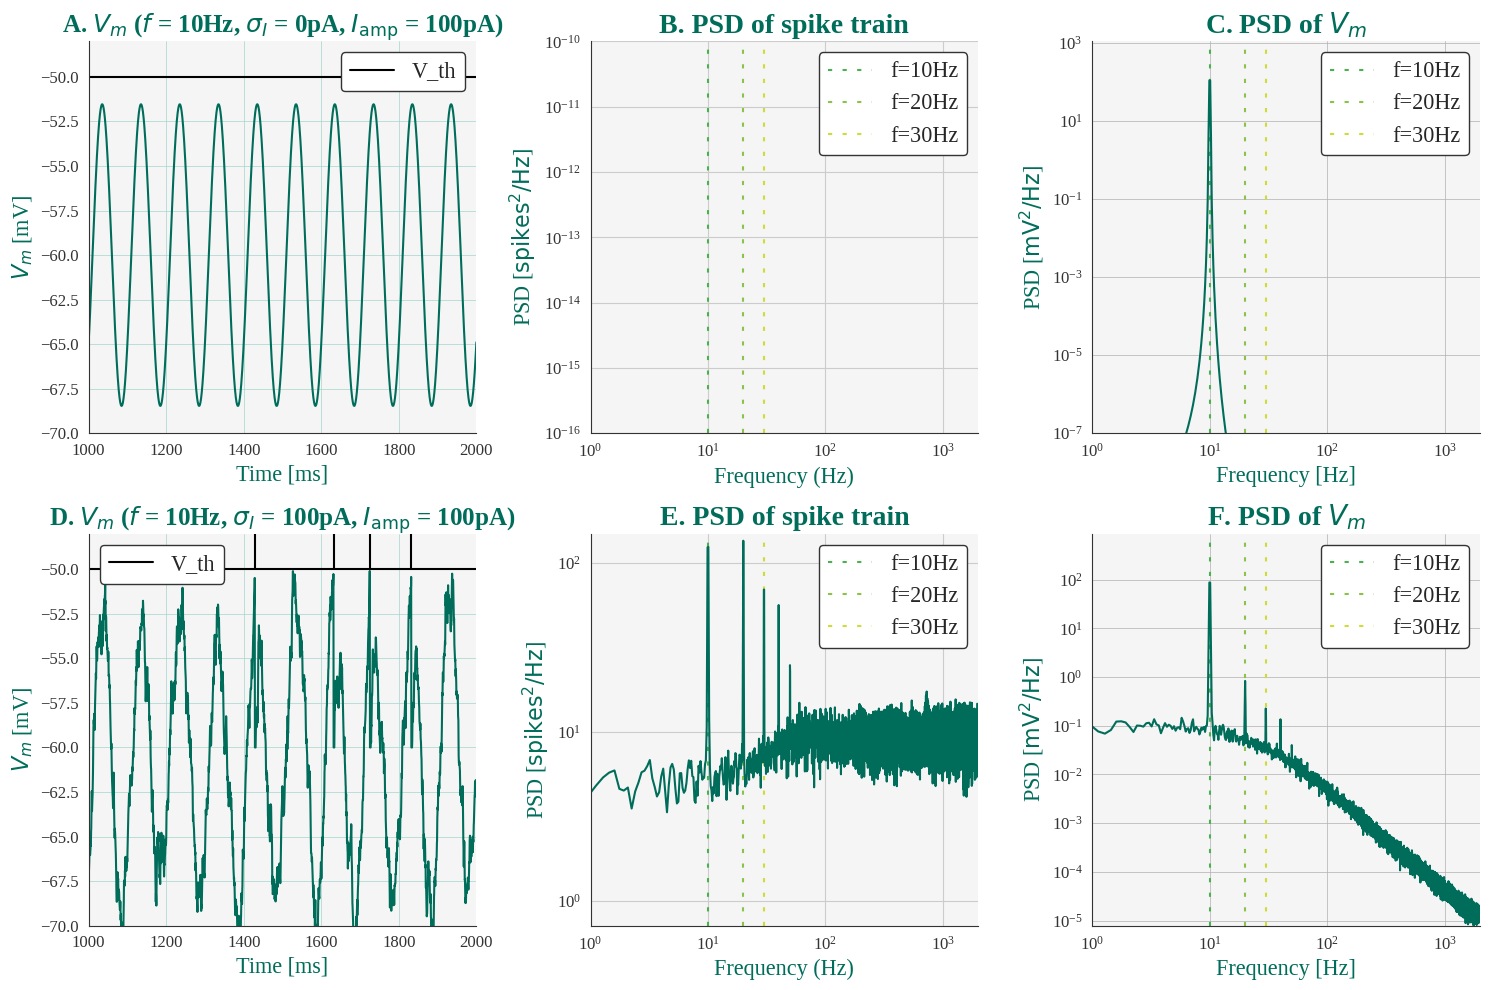

In [63]:
"""stochastic resonance"""
plot_results(sim_time=100000, SD_values=[0,100],
             a_values=[100],f_values=[10], 
             noisy=True, xLim=1, seed=5, bin_size=0.25, second_sine=False,
            harmonics=3, save_fig=False)
